In [1]:
# import packages
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.utils.data import TensorDataset, DataLoader
import torchvision
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Data Generation
# np.random.uniform generates random samples from a uniform distribution over [0, 1).
x = np.random.uniform(low=-2,high=2, size =(100, 1))                              
# the resulting dimension of vector x will be 100 x 1.

# np.random.randn generates random samples from a standard normal distribution.
y = 1 + 2 * x + np.random.randn(100, 1)            

In [3]:
# Shuffles the indices
idx = np.arange(100)
np.random.shuffle(idx)

# Uses first 80 random indices for train
train_idx = idx[:80]
# Uses the remaining indices for validation
val_idx = idx[80:]

# Generates train and validation sets
x_train, y_train = x[train_idx], y[train_idx]
x_val, y_val = x[val_idx], y[val_idx]

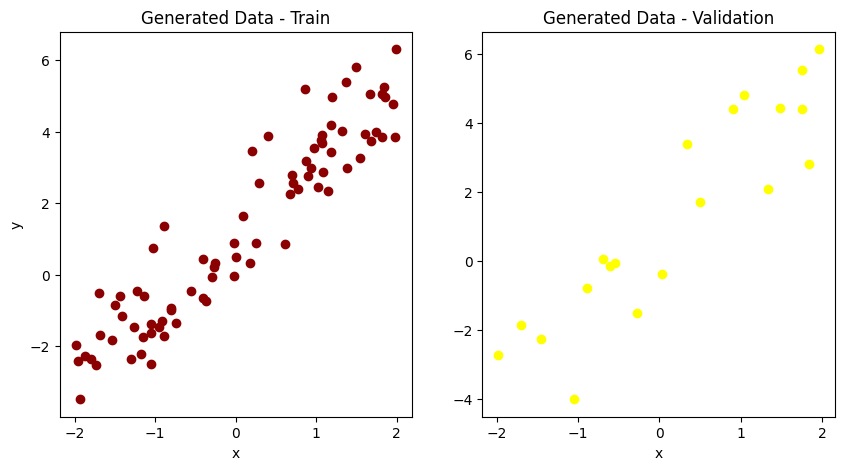

In [6]:
## Below shows a plot of the two sets of data.

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
axes[0].scatter(x_train, y_train, c = 'darkred')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title('Generated Data - Train')
axes[1].scatter(x_val, y_val, c = 'yellow')
axes[1].set_xlabel('x')
axes[1].set_title('Generated Data - Validation')
plt.show()

In [7]:
# Our data was in Numpy arrays, but we need to transform them into PyTorch's Tensors
x_train_tensor = torch.tensor(x_train, dtype=torch.float)      
y_train_tensor = torch.tensor(y_train, dtype=torch.float)
# Here we can see the difference 
print(type(x_train), type(x_train_tensor), x_train_tensor.type())

<class 'numpy.ndarray'> <class 'torch.Tensor'> torch.FloatTensor


In [8]:
# Since we want to apply gradient descent on these parameters, we need
# to set requires_grad = True

### Initialize parameters... 
a = torch.randn(1, requires_grad=True)      
b = torch.randn(1, requires_grad=True)
### ---------------------- 

print(a, b)

tensor([-0.2971], requires_grad=True) tensor([0.5032], requires_grad=True)


In [10]:
# Specifying a learning rate
lr = 1e-1

yhat = a + b * x_train_tensor
error = y_train_tensor - yhat
loss = (error ** 2).mean()

# We just tell PyTorch to work its way BACKWARDS from the specified loss!
loss.backward()
# Let's check the computed gradients...
print('a grad (pytorch)', a.grad)
print('b grad (pytorch)', b.grad)

# compare to actual gradients
with torch.no_grad():
    a_grad = -2 * error.mean()
    b_grad = -2 * (x_train_tensor * error).mean()
print('a grad (manual)', a_grad)
print('b grad (manual)', b_grad)

a grad (pytorch) tensor([-2.8756])
b grad (pytorch) tensor([-2.2259])
a grad (manual) tensor(-2.8756)
b grad (manual) tensor(-2.2259)


In [11]:
n_epochs = 100

for epoch in range(n_epochs):
    yhat = a + b * x_train_tensor
    error = y_train_tensor - yhat
    loss = (error ** 2).mean()

    # No more manual computation of gradients! 
    # a_grad = -2 * error.mean()
    # b_grad = -2 * (x_tensor * error).mean()

    ### We just tell PyTorch to work its way BACKWARDS from the specified loss! 
    loss.backward()            
    ### ---------------------- 

    # Let's check the computed gradients...
    if epoch % 5 == 0:
        print('Epoch:', epoch, '(a, b) grad', a.grad, b.grad)
    
    # Updating the parameters
    with torch.no_grad():
        a -= lr * a.grad
        b -= lr * b.grad
    
    a.grad.zero_()
    b.grad.zero_()
    ### ---------------------- 
    
print('Final (a, b)', a, b)

Epoch: 0 (a, b) grad tensor([-5.7513]) tensor([-4.4517])
Epoch: 5 (a, b) grad tensor([-0.6596]) tensor([-0.1527])
Epoch: 10 (a, b) grad tensor([-0.2131]) tensor([-0.0100])
Epoch: 15 (a, b) grad tensor([-0.0698]) tensor([0.0035])
Epoch: 20 (a, b) grad tensor([-0.0230]) tensor([0.0023])
Epoch: 25 (a, b) grad tensor([-0.0076]) tensor([0.0009])
Epoch: 30 (a, b) grad tensor([-0.0025]) tensor([0.0003])
Epoch: 35 (a, b) grad tensor([-0.0008]) tensor([0.0001])
Epoch: 40 (a, b) grad tensor([-0.0003]) tensor([4.0984e-05])
Epoch: 45 (a, b) grad tensor([-9.2559e-05]) tensor([1.3908e-05])
Epoch: 50 (a, b) grad tensor([-3.0816e-05]) tensor([4.3679e-06])
Epoch: 55 (a, b) grad tensor([-1.0014e-05]) tensor([1.7360e-06])
Epoch: 60 (a, b) grad tensor([-3.4049e-06]) tensor([7.8976e-07])
Epoch: 65 (a, b) grad tensor([-1.3337e-06]) tensor([1.0394e-06])
Epoch: 70 (a, b) grad tensor([-5.8860e-07]) tensor([1.0207e-06])
Epoch: 75 (a, b) grad tensor([-5.8860e-07]) tensor([1.0207e-06])
Epoch: 80 (a, b) grad tenso